In [ ]:
import json
import pandas as pd
from sklearn.metrics import cohen_kappa_score, confusion_matrix
import numpy as np


annotated_df_1 = pd.DataFrame([], columns=['post_text', 'annotation_1'])
annotated_df_2 = pd.DataFrame([], columns=['post_text', 'annotation_2'])



with open('annotation_1.json', 'r', encoding='utf-8') as f:
    annotation_1 = json.load(f)

texts_1 = []
annotations_1 = []

for a in annotation_1:
    text = a['data']['text']
    value = a['annotations'][0]['result'][0]['value']['choices'][0]
    texts_1.append(text)
    annotations_1.append(value)

annotated_df_1['post_text'] = texts_1
annotated_df_1['annotation_1'] = annotations_1



with open('annotation_2.json', 'r', encoding='utf-8') as f:
    annotation_2 = json.load(f)

texts_2 = []
annotations_2 = []

for a in annotation_2:

    text = a['data']['text']
    value = a['annotations'][0]['result'][0]['value']['choices'][0]
    texts_2.append(text)
    annotations_2.append(value)

annotated_df_2['post_text'] = texts_2
annotated_df_2['annotation_2'] = annotations_2

merged_annotation_df = pd.merge(annotated_df_1, annotated_df_2, on='post_text', how='inner')

mismatches = merged_annotation_df[merged_annotation_df['annotation_1'] != merged_annotation_df['annotation_2']]

kappa = cohen_kappa_score(merged_annotation_df['annotation_1'], merged_annotation_df['annotation_2'])

print(f'Mismatches: {len(mismatches)} out of {len(merged_annotation_df)}')
print(f"Cohen's Kappa: {kappa}")


TypeError: '<' not supported between instances of 'float' and 'str'

In [5]:
import nltk
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import roberta_sentiment
from transformers import pipeline, AutoTokenizer, AutoModelForSequenceClassification
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
tokenizer = AutoTokenizer.from_pretrained("cardiffnlp/twitter-roberta-base-sentiment-latest")
model = AutoModelForSequenceClassification.from_pretrained("cardiffnlp/twitter-roberta-base-sentiment-latest")
model.to(device)
model.eval()

pipe = pipeline(
    "text-classification",
    model="cardiffnlp/twitter-roberta-base-sentiment-latest",
    device=-1,
    top_k=None
)

def vader_prediction(text, vaderAnalyzer):
    sentiment = vaderAnalyzer.polarity_scores(text)
    compound = sentiment['compound']
    if compound >= 0.09:
        return "Positive"
    elif compound <= -0.09:
        return "Negative"
    else:
        return "Neutral"

vaderAnalyzer = SentimentIntensityAnalyzer()

merged_annotation_df['vader_sentiment'] = merged_annotation_df['post_text'].apply(lambda x: vader_prediction(x, vaderAnalyzer))
merged_annotation_df['roberta_sentiment'] = merged_annotation_df['post_text'].apply(lambda x: pipe(x)[0][0]['label'].capitalize())

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 
roberta.pooler.dense.bias       | UNEXPECTED |  | 
roberta.pooler.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


-0.5482907
-0.50277805


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 
roberta.pooler.dense.bias       | UNEXPECTED |  | 
roberta.pooler.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 
roberta.pooler.dense.bias       | UNEXPECTED |  | 
roberta.pooler.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


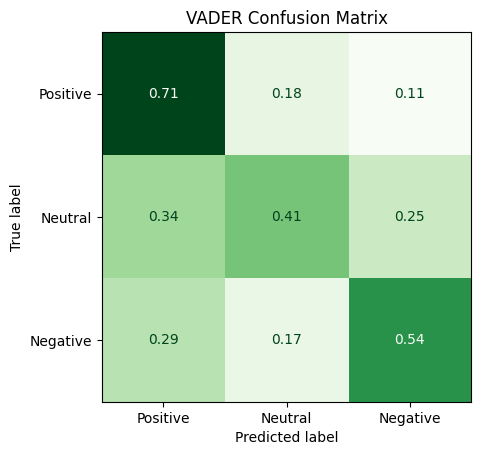

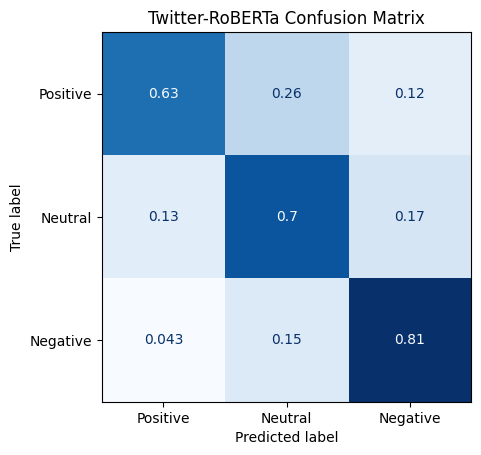

In [6]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

merged_annotation_df['annotation_final'] = merged_annotation_df['annotation_1']
labels=['Positive', 'Neutral', 'Negative']

CMv = confusion_matrix(merged_annotation_df['annotation_final'].tolist(), merged_annotation_df['vader_sentiment'].tolist(), labels = labels, normalize='true')

display = ConfusionMatrixDisplay(confusion_matrix=CMv, display_labels=labels)
display.plot(cmap=plt.cm.Greens, colorbar=False)
display.ax_.set_title("VADER Confusion Matrix")
plt.show()

CMr = confusion_matrix(merged_annotation_df['annotation_final'].tolist(), merged_annotation_df['roberta_sentiment'].tolist(), labels = labels, normalize='true')

display = ConfusionMatrixDisplay(confusion_matrix=CMr, display_labels=labels)
display.plot(cmap=plt.cm.Blues, colorbar=False)
display.ax_.set_title("Twitter-RoBERTa Confusion Matrix")
plt.show()

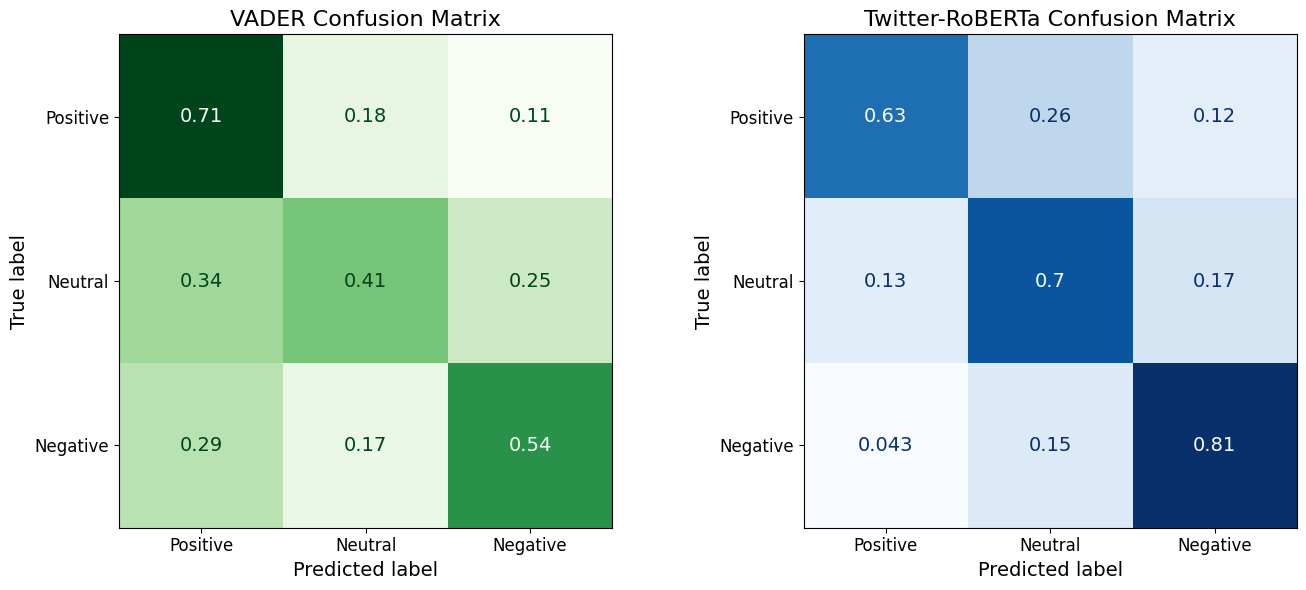

In [7]:

CMv = confusion_matrix(
    merged_annotation_df['annotation_final'].tolist(), 
    merged_annotation_df['vader_sentiment'].tolist(), 
    labels=labels
)

CMr = confusion_matrix(
    merged_annotation_df['annotation_final'].tolist(), 
    merged_annotation_df['roberta_sentiment'].tolist(), 
    labels=labels
)


CMv_norm = confusion_matrix(
    merged_annotation_df['annotation_final'].tolist(), 
    merged_annotation_df['vader_sentiment'].tolist(), 
    labels=labels, normalize='true'
)

CMr_norm = confusion_matrix(
    merged_annotation_df['annotation_final'].tolist(), 
    merged_annotation_df['roberta_sentiment'].tolist(), 
    labels=labels, normalize='true'
)

# Create figure with 2 subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 6))  # side-by-side

# VADER Confusion Matrix with bigger numbers
disp_vader = ConfusionMatrixDisplay(confusion_matrix=CMv_norm, display_labels=labels)
disp_vader.plot(cmap=plt.cm.Greens, colorbar=False, ax=axes[0], text_kw={"fontsize": 14})
axes[0].set_title("VADER Confusion Matrix", fontsize=16)
axes[0].tick_params(axis='both', labelsize=12)
axes[0].set_xlabel("Predicted label", fontsize=14)
axes[0].set_ylabel("True label", fontsize=14)

# RoBERTa Confusion Matrix with bigger numbers
disp_roberta = ConfusionMatrixDisplay(confusion_matrix=CMr_norm, display_labels=labels)
disp_roberta.plot(cmap=plt.cm.Blues, colorbar=False, ax=axes[1], text_kw={"fontsize": 14})
axes[1].set_title("Twitter-RoBERTa Confusion Matrix", fontsize=16)
axes[1].tick_params(axis='both', labelsize=12)
axes[1].set_xlabel("Predicted label", fontsize=14)
axes[1].set_ylabel("True label", fontsize=14)

plt.tight_layout()
plt.show()

In [8]:
wrong_negatives = merged_annotation_df[(merged_annotation_df['annotation_final'] == 'Negative') & (merged_annotation_df['vader_sentiment'] == 'Positive') & (merged_annotation_df['roberta_sentiment'] == 'Negative')]
pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_rows', None)
print(wrong_negatives)

print(len(wrong_negatives))
print(len(merged_annotation_df[(merged_annotation_df['annotation_final'] == 'Negative')]))

                                                                                                                                                                                                                                                                                                            post_text  \
2                                                                                                                                                                                   "Everyone hate AI. But what if AI good actually?"\n\n-- every media outlet owned by a company or individual deeply invested in AI   
34                                                                                    @sharonastyk.bsky.social\nThe war left deep marks on us mentally and physically. My family is doing everything we can to stay strong, but recovery needs support. If you’re able to help, it makes a real difference for us 🙏🏻💔   
86       CBS News has entered unhinged territory. I happened 

In [9]:
print(merged_annotation_df[['post_text', 'annotation_1', 'vader_sentiment', 'roberta_sentiment']].head(20))

                                                                                                                                                                                                                                                                                                     post_text  \
0    just be4 my kid‘s birth his cuz ended up gettin his chosen name 2wks overdue its winter ect all the unwanted stars So   came up w a 26 name list based on the alphabet Achilles…Fabius none made the final cut tho one became his then@that time pre B&tB nickname& might make4 a good dogs #Baby #Gaston   
1                                                                                                                                                                                                                           "Cold here in Wales. And they got all these mammals." - Taz. \n\nWe are so back. 🤼   
2                                                                                 

In [10]:
print('Twitter-RoBERTa:')
print(CMr)
print('VADER:')
print(CMv)

Twitter-RoBERTa:
[[123  50  23]
 [ 37 206  51]
 [ 11  37 206]]
VADER:
[[139  35  22]
 [100 120  74]
 [ 74  42 138]]


In [11]:
# Normalized confusion matrices (row = true, col = predicted)
CM_roberta = np.array(CMr)

CM_vader = np.array(CMv)

def compute_metrics(CM, model_name):
    metrics = []
    CM = np.array(CM)
    for i, label in enumerate(labels):
        TP = CM[i, i]
        FN = CM[i, :].sum() - TP
        FP = CM[:, i].sum() - TP
        precision = TP / (TP + FP) if (TP + FP) != 0 else 0
        recall = TP / (TP + FN) if (TP + FN) != 0 else 0
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) != 0 else 0
        metrics.append({
            'Model': model_name,
            'Class': label,
            'Precision': precision,
            'Recall': recall,
            'F1-score': f1
        })
    accuracy = np.trace(CM) / CM.sum()  # sum of diagonals / total sum
    for m in metrics:
        m['Accuracy'] = accuracy  # same accuracy for all classes
    return metrics

# Compute metrics for both models
metrics_roberta = compute_metrics(CM_roberta, 'RoBERTa-Twitter')
metrics_vader = compute_metrics(CM_vader, 'VADER')

# Combine into one DataFrame
df_metrics = pd.DataFrame(metrics_roberta + metrics_vader)

# Optional: round numbers for readability
df_metrics[['Precision', 'Recall', 'F1-score', 'Accuracy']] = df_metrics[['Precision', 'Recall', 'F1-score', 'Accuracy']].round(3)

# Display table
print(df_metrics)

             Model     Class  Precision  Recall  F1-score  Accuracy
0  RoBERTa-Twitter  Positive      0.719   0.628     0.670     0.719
1  RoBERTa-Twitter   Neutral      0.703   0.701     0.702     0.719
2  RoBERTa-Twitter  Negative      0.736   0.811     0.772     0.719
3            VADER  Positive      0.444   0.709     0.546     0.534
4            VADER   Neutral      0.609   0.408     0.489     0.534
5            VADER  Negative      0.590   0.543     0.566     0.534
